# Date Alignment: News to Stock Trading Days

This notebook normalizes timestamps across news and stock datasets to match news items to their corresponding stock trading days.

## Objectives:
- **Standardize date formats** between news and stock data
- **Handle timezone differences** in news timestamps
- **Map news articles to trading days** considering market hours
- **Validate alignment accuracy** with visualizations
- **Create aligned dataset** for further analysis

In [28]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, time, timezone
import warnings
from pathlib import Path
import pytz

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Date alignment libraries imported successfully!")

Date alignment libraries imported successfully!


## 1. Load and Examine Datasets

In [29]:
# Define data paths
news_data_path = '../Data/newsData/raw_analyst_ratings.csv'
stock_data_dir = '../Data/yfinance_data/Data/'

# Load news data
print("Loading news data...")
news_df = pd.read_csv(news_data_path)
print(f"News data loaded: {news_df.shape[0]:,} articles")
print(f"News columns: {news_df.columns.tolist()}")
print(f"News date range: {news_df['date'].min()} to {news_df['date'].max()}")

# Load stock data files
print("\nLoading stock data...")
stock_files = list(Path(stock_data_dir).glob('*.csv'))
print(f"Found {len(stock_files)} stock files: {[f.name for f in stock_files]}")

# Load all stock data into a dictionary
stock_data = {}
for file_path in stock_files:
    symbol = file_path.stem
    stock_df = pd.read_csv(file_path)
    stock_df['Symbol'] = symbol
    stock_data[symbol] = stock_df
    print(f"{symbol}: {stock_df.shape[0]} trading days from {stock_df['Date'].min()} to {stock_df['Date'].max()}")

Loading news data...
News data loaded: 1,407,328 articles
News columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']
News date range: 2009-02-14 00:00:00 to 2020-06-11 17:12:35-04:00

Loading stock data...
Found 5 stock files: ['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv']
AAPL: 3774 trading days from 2009-01-02 to 2023-12-29
AMZN: 3774 trading days from 2009-01-02 to 2023-12-29
GOOG: 3774 trading days from 2009-01-02 to 2023-12-29
META: 2923 trading days from 2012-05-18 to 2023-12-29
NVDA: 3774 trading days from 2009-01-02 to 2023-12-29


## 2. Analyze Date Formats and Timezones

In [30]:
# Analyze news date format
print("NEWS DATA DATE ANALYSIS:")
print("=" * 50)
print(f"Original date type: {news_df['date'].dtype}")
print(f"Sample dates:")
for i in range(5):
    print(f"  {i+1}. {news_df['date'].iloc[i]}")

# Check for timezone information
has_timezone = news_df['date'].str.contains(r'[+-]\d{2}:\d{2}$', na=False).any()
print(f"\nHas timezone info: {has_timezone}")

# Analyze stock date format
print(f"\nSTOCK DATA DATE ANALYSIS:")
print("=" * 50)
sample_stock = list(stock_data.values())[0]
print(f"Stock date type: {sample_stock['Date'].dtype}")
print(f"Sample stock dates:")
for i in range(5):
    print(f"  {i+1}. {sample_stock['Date'].iloc[i]}")

# Check unique stock symbols in news data
print(f"\nNEWS STOCK SYMBOLS:")
print("=" * 50)
news_stocks = news_df['stock'].value_counts()
print(f"Unique symbols in news: {len(news_stocks)}")
print(f"Top 10 symbols: {news_stocks.head(10).to_dict()}")

NEWS DATA DATE ANALYSIS:
Original date type: str
Sample dates:
  1. 2020-06-05 10:30:54-04:00
  2. 2020-06-03 10:45:20-04:00
  3. 2020-05-26 04:30:07-04:00
  4. 2020-05-22 12:45:06-04:00
  5. 2020-05-22 11:38:59-04:00

Has timezone info: True

STOCK DATA DATE ANALYSIS:
Stock date type: str
Sample stock dates:
  1. 2009-01-02
  2. 2009-01-05
  3. 2009-01-06
  4. 2009-01-07
  5. 2009-01-08

NEWS STOCK SYMBOLS:
Unique symbols in news: 6204
Top 10 symbols: {'MRK': 3333, 'MS': 3238, 'NVDA': 3146, 'MU': 3142, 'QQQ': 3106, 'NFLX': 3028, 'M': 3025, 'EBAY': 3018, 'GILD': 2968, 'VZ': 2966}


## 3. Normalize News Timestamps

In [31]:
def normalize_news_timestamps(df):
    """
    Normalize news timestamps to UTC and extract date components
    """
    # Create a copy to avoid modifying original
    normalized_df = df.copy()
    
    # Convert to datetime, handling timezone information
    print("Converting news timestamps to datetime...")
    
    # First, try to parse with timezone info
    normalized_df['datetime_utc'] = pd.to_datetime(normalized_df['date'], utc=True, errors='coerce')
    
    # Check for any failed conversions
    failed_conversions = normalized_df['datetime_utc'].isna().sum()
    if failed_conversions > 0:
        print(f"Warning: {failed_conversions} timestamps failed to convert")
        # Try alternative parsing for failed ones
        mask = normalized_df['datetime_utc'].isna()
        normalized_df.loc[mask, 'datetime_utc'] = pd.to_datetime(
            normalized_df.loc[mask, 'date'],
            utc=True,
            errors='coerce'
        )
    
    # Extract date components
    normalized_df['date_utc'] = normalized_df['datetime_utc'].dt.date
    normalized_df['time_utc'] = normalized_df['datetime_utc'].dt.time
    normalized_df['hour_utc'] = normalized_df['datetime_utc'].dt.hour
    normalized_df['day_of_week_utc'] = normalized_df['datetime_utc'].dt.dayofweek  # 0=Monday
    
    # Convert to US Eastern Time (market timezone)
    eastern = pytz.timezone('US/Eastern')
    normalized_df['datetime_et'] = normalized_df['datetime_utc'].dt.tz_convert(eastern)
    normalized_df['date_et'] = normalized_df['datetime_et'].dt.date
    normalized_df['time_et'] = normalized_df['datetime_et'].dt.time
    normalized_df['hour_et'] = normalized_df['datetime_et'].dt.hour
    
    # Flag market hours (9:30 AM - 4:00 PM ET)
    market_open = time(9, 30)
    market_close = time(16, 0)
    
    def is_market_hours(t):
        return market_open <= t <= market_close
    
    normalized_df['is_market_hours_et'] = normalized_df['time_et'].apply(is_market_hours)
    
    print(f"Successfully normalized {len(normalized_df)} news timestamps")
    print(f"Date range (UTC): {normalized_df['datetime_utc'].min()} to {normalized_df['datetime_utc'].max()}")
    print(f"Date range (ET): {normalized_df['datetime_et'].min()} to {normalized_df['datetime_et'].max()}")
    
    return normalized_df

# Apply normalization
news_normalized = normalize_news_timestamps(news_df)

# Display sample of normalized data
print(f"\nSample of normalized news data:")
display_cols = ['headline', 'stock', 'date', 'datetime_utc', 'datetime_et', 'hour_et', 'is_market_hours_et']
print(news_normalized[display_cols].head(10))

Converting news timestamps to datetime...
Successfully normalized 1407328 news timestamps
Date range (UTC): 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
Date range (ET): 2009-02-13 19:00:00-05:00 to 2020-06-11 17:12:35-04:00

Sample of normalized news data:
                                            headline stock  \
0            Stocks That Hit 52-Week Highs On Friday     A   
1         Stocks That Hit 52-Week Highs On Wednesday     A   
2                      71 Biggest Movers From Friday     A   
3       46 Stocks Moving In Friday's Mid-Day Session     A   
4  B of A Securities Maintains Neutral on Agilent...     A   
5  CFRA Maintains Hold on Agilent Technologies, L...     A   
6  UBS Maintains Neutral on Agilent Technologies,...     A   
7  Agilent Technologies shares are trading higher...     A   
8  Wells Fargo Maintains Overweight on Agilent Te...     A   
9         10 Biggest Price Target Changes For Friday     A   

                        date              datetim

## 4. Normalize Stock Data and Create Trading Calendar

In [32]:
def normalize_stock_data(stock_data_dict):
    """
    Normalize stock data and create a unified trading calendar
    """
    all_stock_data = []
    trading_dates = set()
    
    print("Normalizing stock data...")
    
    for symbol, df in stock_data_dict.items():
        # Convert Date column to datetime
        df_normalized = df.copy()
        df_normalized['Date'] = pd.to_datetime(df_normalized['Date'])
        df_normalized['date_only'] = df_normalized['Date'].dt.date
        
        # Add to trading dates set
        trading_dates.update(df_normalized['date_only'].tolist())
        
        all_stock_data.append(df_normalized)
        
        print(f"{symbol}: {len(df_normalized)} trading days")
    
    # Combine all stock data
    combined_stock_df = pd.concat(all_stock_data, ignore_index=True)
    
    # Create trading calendar
    trading_dates_sorted = sorted(list(trading_dates))
    trading_calendar = pd.DataFrame({
        'trading_date': trading_dates_sorted,
        'date_index': range(len(trading_dates_sorted))
    })
    
    trading_calendar['datetime'] = pd.to_datetime(trading_calendar['trading_date'])
    trading_calendar['day_of_week'] = trading_calendar['datetime'].dt.dayofweek
    trading_calendar['is_weekday'] = trading_calendar['day_of_week'] < 5
    
    print(f"\nTrading calendar created:")
    print(f"Total trading days: {len(trading_calendar)}")
    print(f"Date range: {trading_calendar['trading_date'].min()} to {trading_calendar['trading_date'].max()}")
    print(f"Weekend days in calendar: {(~trading_calendar['is_weekday']).sum()}")
    
    return combined_stock_df, trading_calendar

# Apply normalization
stock_combined, trading_calendar = normalize_stock_data(stock_data)

# Display sample
print(f"\nSample of combined stock data:")
print(stock_combined[['Symbol', 'Date', 'Close', 'Volume']].head(10))

print(f"\nSample of trading calendar:")
print(trading_calendar.head(10))

Normalizing stock data...
AAPL: 3774 trading days
AMZN: 3774 trading days
GOOG: 3774 trading days
META: 2923 trading days
NVDA: 3774 trading days

Trading calendar created:
Total trading days: 3774
Date range: 2009-01-02 to 2023-12-29
Weekend days in calendar: 0

Sample of combined stock data:
  Symbol       Date     Close      Volume
0   AAPL 2009-01-02  2.721686   746015200
1   AAPL 2009-01-05  2.836553  1181608400
2   AAPL 2009-01-06  2.789767  1289310400
3   AAPL 2009-01-07  2.729484   753048800
4   AAPL 2009-01-08  2.780169   673500800
5   AAPL 2009-01-09  2.716589   546845600
6   AAPL 2009-01-12  2.659007   617716400
7   AAPL 2009-01-13  2.630514   798397600
8   AAPL 2009-01-14  2.559135  1021664000
9   AAPL 2009-01-15  2.500652  1831634000

Sample of trading calendar:
  trading_date  date_index   datetime  day_of_week  is_weekday
0   2009-01-02           0 2009-01-02            4        True
1   2009-01-05           1 2009-01-05            0        True
2   2009-01-06           

## 5. Map News to Trading Days

In [33]:
# Apply enhanced mapping
news_mapped_enhanced = map_news_to_trading_days_enhanced(news_normalized, trading_calendar)

# Analyze enhanced mapping results
print(f"\nENHANCED MAPPING ANALYSIS:")
print("=" * 60)
print(f"Total news articles: {len(news_mapped_enhanced):,}")
print(f"Successfully mapped: {news_mapped_enhanced['target_trading_day'].notna().sum():,}")
print(f"Failed mappings: {news_mapped_enhanced['target_trading_day'].isna().sum():,}")

# Days to trading day distribution
days_dist = news_mapped_enhanced['days_to_trading_day'].value_counts().sort_index()
print(f"\nDays to target trading day:")
for days, count in days_dist.items():
    print(f"  {days} days: {count:,} articles ({count/len(news_mapped_enhanced)*100:.1f}%)")

# Mapping type distribution
mapping_type_dist = news_mapped_enhanced['mapping_type'].value_counts()
print(f"\nMapping type distribution:")
for mapping_type, count in mapping_type_dist.items():
    print(f"  {mapping_type}: {count:,} articles ({count/len(news_mapped_enhanced)*100:.1f}%)")

# Weekend and holiday analysis
weekend_articles = news_mapped_enhanced['is_weekend'].sum()
holiday_articles = news_mapped_enhanced['is_holiday'].sum()
print(f"\nWeekend and holiday analysis:")
print(f"  Weekend articles: {weekend_articles:,} ({weekend_articles/len(news_mapped_enhanced)*100:.1f}%)")
print(f"  Holiday articles: {holiday_articles:,} ({holiday_articles/len(news_mapped_enhanced)*100:.1f}%)")

# Market hours vs after hours
market_hours_count = news_mapped_enhanced['is_market_hours_et'].sum()
after_hours_count = len(news_mapped_enhanced) - market_hours_count
print(f"\nMarket hours distribution:")
print(f"  Market hours: {market_hours_count:,} ({market_hours_count/len(news_mapped_enhanced)*100:.1f}%)")
print(f"  After hours: {after_hours_count:,} ({after_hours_count/len(news_mapped_enhanced)*100:.1f}%)")

Mapping news to trading days with enhanced weekend/holiday handling...
Successfully mapped 1407328 news articles to trading days

ENHANCED MAPPING ANALYSIS:
Total news articles: 1,407,328
Successfully mapped: 1,407,328
Failed mappings: 0

Days to target trading day:
  0 days: 26,959 articles (1.9%)
  1 days: 1,348,552 articles (95.8%)
  2 days: 18,095 articles (1.3%)
  3 days: 12,182 articles (0.9%)
  4 days: 1,533 articles (0.1%)
  5 days: 7 articles (0.0%)

Mapping type distribution:
  after_hours_to_next_day: 1,074,941 articles (76.4%)
  weekend_to_next_trading: 271,622 articles (19.3%)
  holiday_to_next_trading: 33,806 articles (2.4%)
  market_hours_same_day: 26,959 articles (1.9%)

Weekend and holiday analysis:
  Weekend articles: 271,622 (19.3%)
  Holiday articles: 33,806 (2.4%)

Market hours distribution:
  Market hours: 27,325 (1.9%)
  After hours: 1,380,003 (98.1%)


In [34]:
# Perform weekend and holiday validation
weekend_holiday_stats = validate_weekend_holiday_mappings(news_mapped_enhanced, trading_calendar)

WEEKEND AND HOLIDAY MAPPING VALIDATION

1. WEEKEND MAPPING ANALYSIS:
   Weekend articles: 271,622
   Saturday: 16,344 articles
   Sunday: 255,278 articles

   Weekend mapping to next trading day:
   1 days: 252,887 articles (93.1%)
   2 days: 17,313 articles (6.4%)
   3 days: 1,418 articles (0.5%)
   4 days: 4 articles (0.0%)

   Sample weekend mappings:
   2020-05-17 (Weekend) → 2020-05-18 (1 days)
   2020-04-05 (Weekend) → 2020-04-06 (1 days)
   2020-03-29 (Weekend) → 2020-03-30 (1 days)
   2020-03-29 (Weekend) → 2020-03-30 (1 days)
   2020-03-15 (Weekend) → 2020-03-16 (1 days)

2. HOLIDAY MAPPING ANALYSIS:
   Holiday articles: 33,806

   Holiday mapping to next trading day:
   1 days: 33,406 articles (98.8%)
   2 days: 230 articles (0.7%)
   3 days: 170 articles (0.5%)

   Sample holiday mappings:
   2020-02-17 (Holiday) → 2020-02-18 (1 days)
   2020-02-17 (Holiday) → 2020-02-18 (1 days)
   2020-02-17 (Holiday) → 2020-02-18 (1 days)
   2020-02-17 (Holiday) → 2020-02-18 (1 days)
   2

In [35]:
## 5.2. Test Enhanced Mapping with Sample Data

def test_enhanced_mapping_with_samples():
    """
    Test the enhanced mapping logic with sample weekend and holiday scenarios
    """
    print("TESTING ENHANCED MAPPING WITH SAMPLE DATA")
    print("=" * 50)
    
    # Create sample test cases
    test_cases = [
        # Weekend cases
        {'date': '2020-06-06 18:00:00-04:00', 'stock': 'AAPL', 'headline': 'Saturday evening news'},
        {'date': '2020-06-07 10:00:00-04:00', 'stock': 'AAPL', 'headline': 'Sunday morning news'},
        {'date': '2020-06-07 15:00:00-04:00', 'stock': 'AAPL', 'headline': 'Sunday afternoon news'},
        
        # Friday after hours (should map to Monday)
        {'date': '2020-06-05 16:30:00-04:00', 'stock': 'AAPL', 'headline': 'Friday after hours'},
        {'date': '2020-06-05 20:00:00-04:00', 'stock': 'AAPL', 'headline': 'Friday evening news'},
        
        # Monday morning before market (should map to Monday)
        {'date': '2020-06-08 08:00:00-04:00', 'stock': 'AAPL', 'headline': 'Monday pre-market'},
        
        # During market hours (should map to same day)
        {'date': '2020-06-08 10:30:00-04:00', 'stock': 'AAPL', 'headline': 'Monday market hours'},
        {'date': '2020-06-08 14:00:00-04:00', 'stock': 'AAPL', 'headline': 'Monday afternoon'},
    ]
    
    # Create test DataFrame
    test_df = pd.DataFrame(test_cases)
    
    # Normalize timestamps using the same function
    test_normalized = normalize_news_timestamps(test_df)
    
    # Apply enhanced mapping
    test_mapped = map_news_to_trading_days_enhanced(test_normalized, trading_calendar)
    
    print(f"\nTest Results:")
    print("-" * 50)
    
    for _, row in test_mapped.iterrows():
        news_date = row['date_et']
        target_date = row['target_trading_day']
        days_diff = row['days_to_trading_day']
        mapping_type = row['mapping_type']
        is_weekend = row['is_weekend']
        is_market_hours = row['is_market_hours_et']
        
        print(f"\n📰 {row['headline']}")
        print(f"   News Date: {news_date} ({'Weekend' if is_weekend else 'Weekday'})")
        print(f"   Market Hours: {'Yes' if is_market_hours else 'No'}")
        print(f"   Target Trading Day: {target_date}")
        print(f"   Days Difference: {days_diff}")
        print(f"   Mapping Type: {mapping_type}")
    
    # Validate that all targets are trading days
    trading_days_set = set(trading_calendar['trading_date'])
    all_valid_targets = all(test_mapped['target_trading_day'].isin(trading_days_set))
    
    print(f"\n✅ Validation Results:")
    print(f"   All targets are valid trading days: {all_valid_targets}")
    
    return test_mapped

# Run the test
test_results = test_enhanced_mapping_with_samples()

TESTING ENHANCED MAPPING WITH SAMPLE DATA
Converting news timestamps to datetime...
Successfully normalized 8 news timestamps
Date range (UTC): 2020-06-05 20:30:00+00:00 to 2020-06-08 18:00:00+00:00
Date range (ET): 2020-06-05 16:30:00-04:00 to 2020-06-08 14:00:00-04:00
Mapping news to trading days with enhanced weekend/holiday handling...
Successfully mapped 8 news articles to trading days

Test Results:
--------------------------------------------------

📰 Saturday evening news
   News Date: 2020-06-06 (Weekend)
   Market Hours: No
   Target Trading Day: 2020-06-08
   Days Difference: 2
   Mapping Type: weekend_to_next_trading

📰 Sunday morning news
   News Date: 2020-06-07 (Weekend)
   Market Hours: Yes
   Target Trading Day: 2020-06-08
   Days Difference: 1
   Mapping Type: weekend_to_next_trading

📰 Sunday afternoon news
   News Date: 2020-06-07 (Weekend)
   Market Hours: Yes
   Target Trading Day: 2020-06-08
   Days Difference: 1
   Mapping Type: weekend_to_next_trading

📰 Friday

In [39]:
# Create enhanced aligned dataset
aligned_dataset_enhanced = create_aligned_dataset(news_mapped_enhanced, stock_combined, trading_calendar)

# Display sample
print(f"\nSample of enhanced aligned dataset:")
display_cols = [
    'trading_date', 'stock', 'article_count', 'unique_publishers',
    'Close', 'Volume', 'market_hours_ratio', 'primary_mapping_type',
    'weekend_ratio', 'holiday_ratio'
]
print(aligned_dataset_enhanced[display_cols].head(15))

# Compare with original alignment
print(f"\nCOMPARISON: Original vs Enhanced Alignment")
print("=" * 60)
print(f"Original aligned records: {len(aligned_dataset):,}")
print(f"Enhanced aligned records: {len(aligned_dataset_enhanced):,}")
print(f"Difference: {len(aligned_dataset_enhanced) - len(aligned_dataset):+,}")

# Check if we have improved weekend/holiday handling
if 'primary_mapping_type' in aligned_dataset_enhanced.columns:
    mapping_types = aligned_dataset_enhanced['primary_mapping_type'].value_counts()
    print(f"\nMapping types in enhanced dataset:")
    for mapping_type, count in mapping_types.items():
        print(f"  {mapping_type}: {count:,} records")

Creating enhanced aligned dataset...
Enhanced aligned dataset created:
Total aligned records: 1,589
Unique stocks: 4
Date range: 2011-03-03 to 2020-06-11

Sample of enhanced aligned dataset:
   trading_date stock  article_count  unique_publishers     Close      Volume  \
0    2011-03-03  NVDA              1                  1  0.478385  1593704000   
1    2011-03-07  NVDA              2                  2  0.469216  1019140000   
2    2011-03-08  NVDA              4                  4  0.448128  1947184000   
3    2011-03-09  NVDA              3                  3  0.438730  1318976000   
4    2011-03-10  NVDA              2                  1  0.410765  1722736000   
5    2011-03-15  NVDA              3                  3  0.404805  1256280000   
6    2011-03-16  NVDA              3                  2  0.401825  1476520000   
7    2011-03-22  NVDA              1                  1  0.399991   718332000   
8    2011-03-24  NVDA              3                  2  0.440793  1780592000   

In [40]:
# Perform validation
yearly_stats, stock_stats = validate_alignment(news_mapped_enhanced, aligned_dataset_enhanced, trading_calendar)

ALIGNMENT VALIDATION

1. COVERAGE ANALYSIS:
   Total news articles with valid mapping: 1,407,328
   Articles in aligned dataset: 5,064
   Coverage rate: 0.4%

2. TEMPORAL DISTRIBUTION:
   2011: 226 articles, 1 stocks
   2012: 183 articles, 1 stocks
   2013: 144 articles, 1 stocks
   2014: 118 articles, 1 stocks
   2015: 180 articles, 1 stocks
   2016: 337 articles, 1 stocks
   2017: 614 articles, 1 stocks
   2018: 574 articles, 2 stocks
   2019: 1,221 articles, 2 stocks
   2020: 1,467 articles, 4 stocks

3. STOCK COVERAGE:
   Stocks with news coverage: 4
   Average articles per stock: 1266.0
   Average trading days per stock: 397.2

4. NEWS TIMING ANALYSIS:
   Average market hours ratio: 0.01
   Articles per publisher (avg): 1.21

5. MISSING DATA CHECK:
   Columns with missing data:
     std_hour: 596 (37.5%)


## 8. Visualizations of Alignment Results

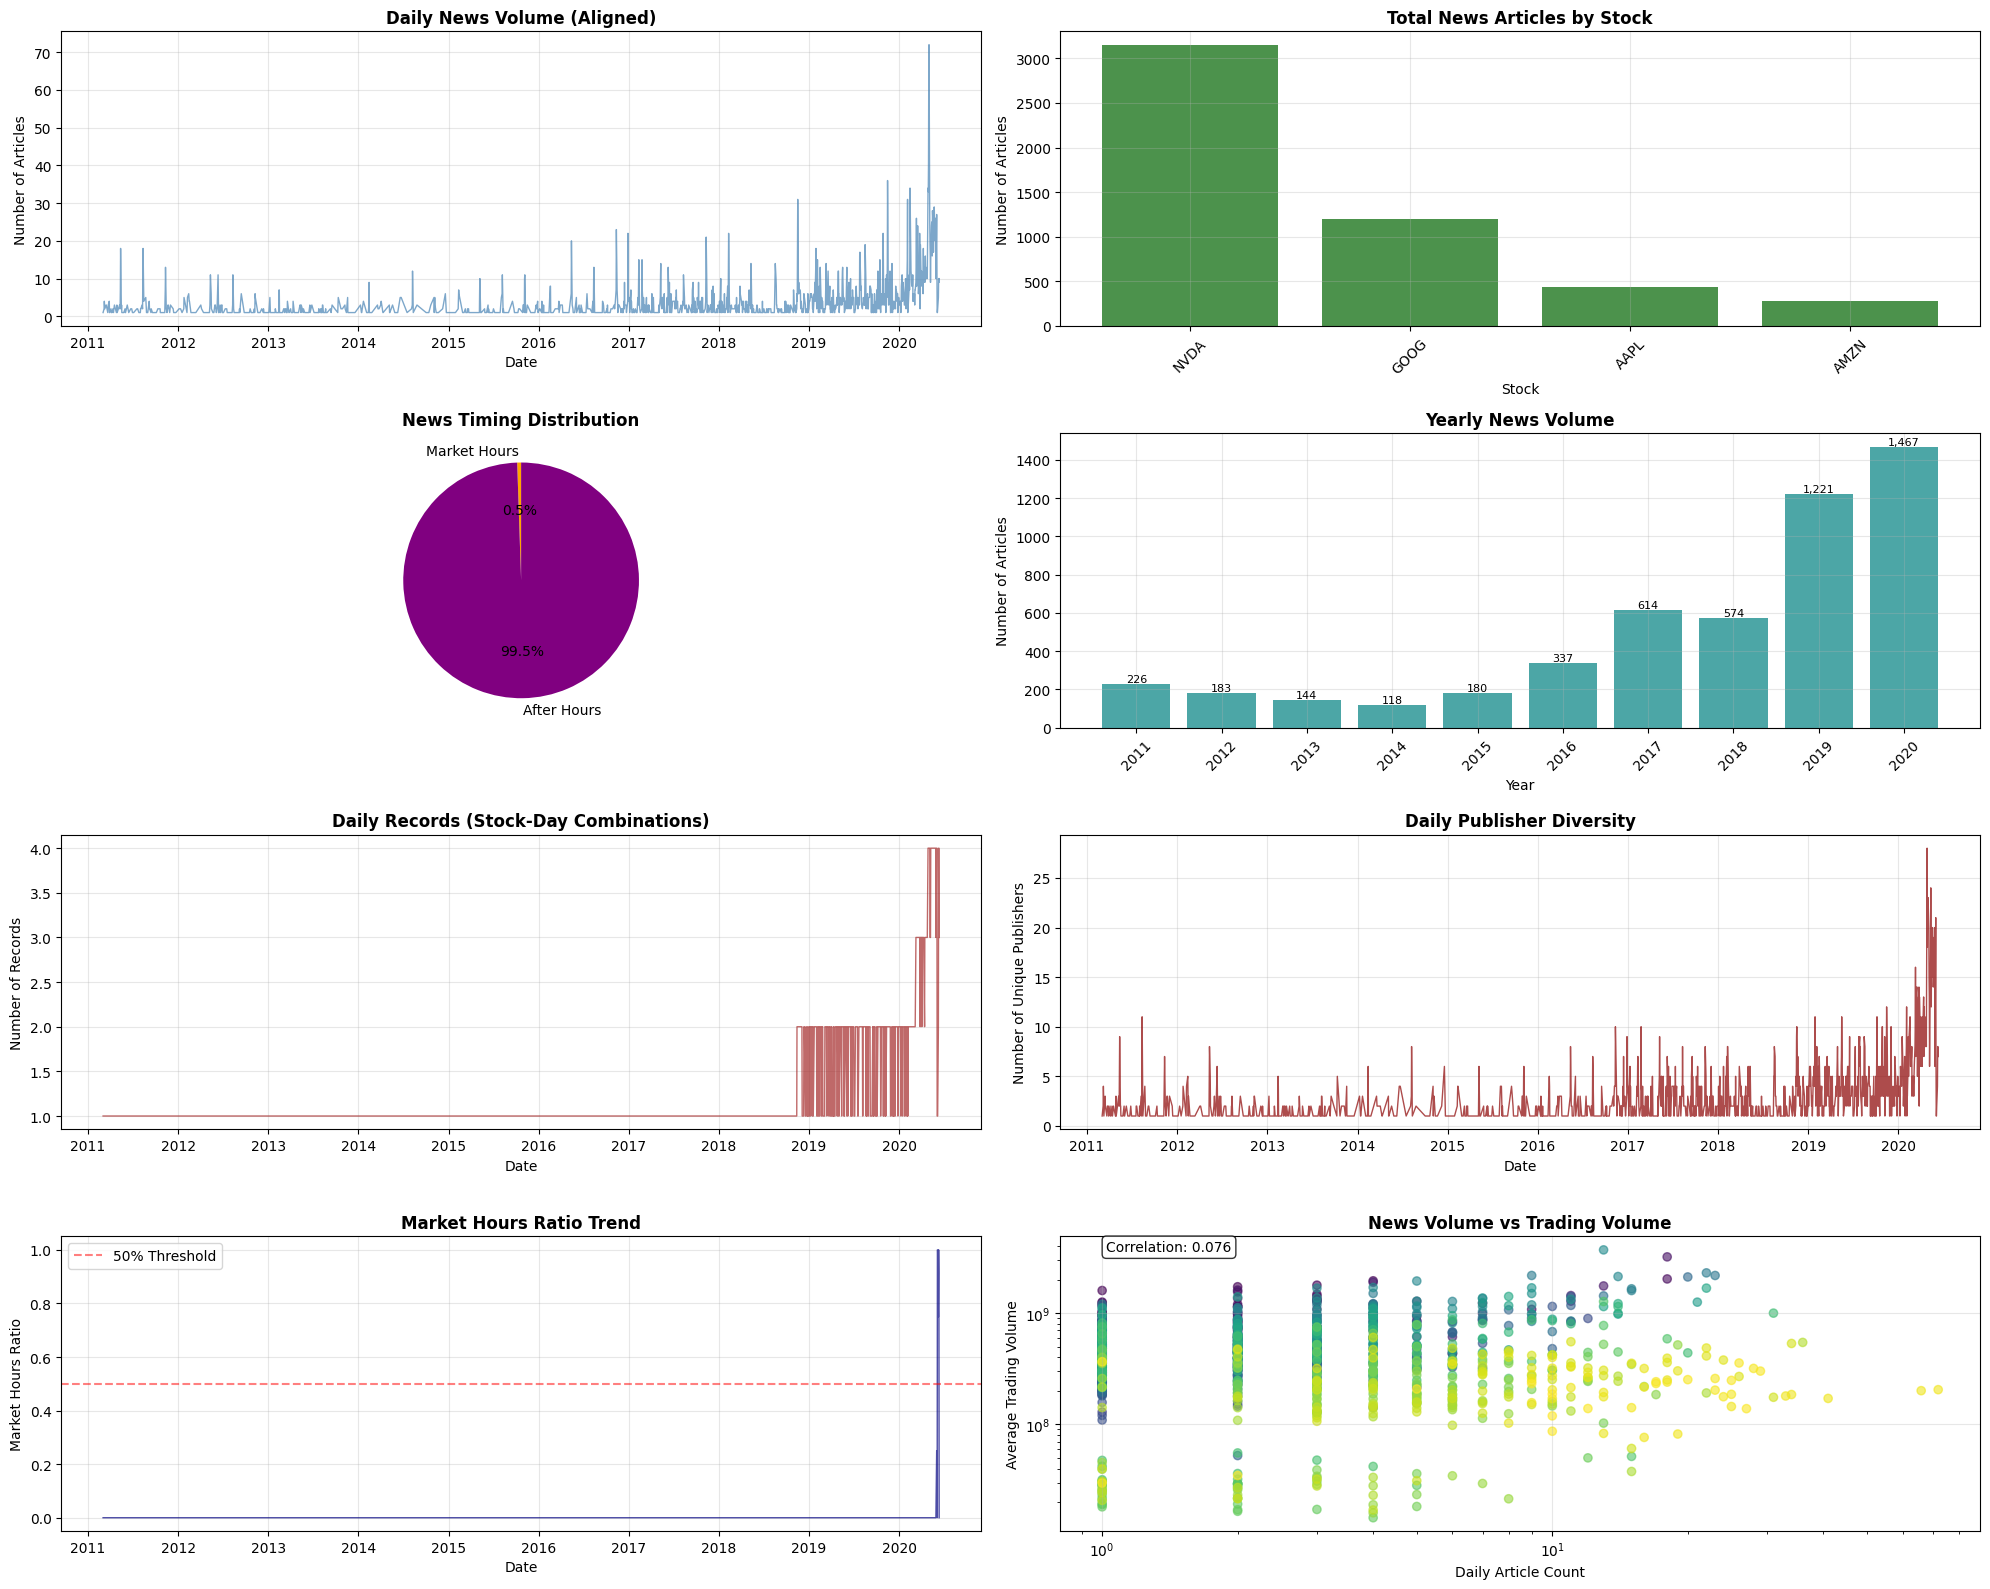

Alignment visualization dashboard created!


In [42]:
# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(20, 16))

# 1. News Volume Over Time
ax1 = plt.subplot(4, 2, 1)
daily_news = aligned_dataset.groupby('trading_date')['article_count'].sum().reset_index()
daily_news['trading_date'] = pd.to_datetime(daily_news['trading_date'])
ax1.plot(daily_news['trading_date'], daily_news['article_count'], 
         color='steelblue', linewidth=1, alpha=0.7)
ax1.set_title('Daily News Volume (Aligned)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Articles')
ax1.grid(True, alpha=0.3)

# 2. News by Stock
ax2 = plt.subplot(4, 2, 2)
stock_news = aligned_dataset.groupby('stock')['article_count'].sum().sort_values(ascending=False)
bars = ax2.bar(range(len(stock_news)), stock_news.values, color='darkgreen', alpha=0.7)
ax2.set_title('Total News Articles by Stock', fontweight='bold', fontsize=12)
ax2.set_xlabel('Stock')
ax2.set_ylabel('Number of Articles')
ax2.set_xticks(range(len(stock_news)))
ax2.set_xticklabels(stock_news.index, rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Market Hours vs After Hours
ax3 = plt.subplot(4, 2, 3)
market_hours_dist = [
    aligned_dataset['market_hours_articles'].sum(),
    (aligned_dataset['article_count'] - aligned_dataset['market_hours_articles']).sum()
]
labels = ['Market Hours', 'After Hours']
colors = ['orange', 'purple']
ax3.pie(market_hours_dist, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax3.set_title('News Timing Distribution', fontweight='bold', fontsize=12)

aligned_dataset['year'] = pd.to_datetime(aligned_dataset['trading_date']).dt.year

# 4. Year-over-Year Comparison
ax4 = plt.subplot(4, 2, 4)
yearly_data = aligned_dataset.groupby('year')['article_count'].sum().reset_index()
bars = ax4.bar(yearly_data['year'].astype(str), yearly_data['article_count'], 
               color='teal', alpha=0.7)
ax4.set_title('Yearly News Volume', fontweight='bold', fontsize=12)
ax4.set_xlabel('Year')
ax4.set_ylabel('Number of Articles')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=8)

# 5. Trading Days Coverage
ax5 = plt.subplot(4, 2, 5)
trading_day_coverage = aligned_dataset.groupby('trading_date').size().reset_index(name='records')
trading_day_coverage['trading_date'] = pd.to_datetime(trading_day_coverage['trading_date'])
ax5.plot(trading_day_coverage['trading_date'], trading_day_coverage['records'], 
         color='brown', linewidth=1, alpha=0.7)
ax5.set_title('Daily Records (Stock-Day Combinations)', fontweight='bold', fontsize=12)
ax5.set_xlabel('Date')
ax5.set_ylabel('Number of Records')
ax5.grid(True, alpha=0.3)

# 6. Publisher Diversity
ax6 = plt.subplot(4, 2, 6)
publisher_stats = aligned_dataset.groupby('trading_date')['unique_publishers'].sum().reset_index()
publisher_stats['trading_date'] = pd.to_datetime(publisher_stats['trading_date'])
ax6.plot(publisher_stats['trading_date'], publisher_stats['unique_publishers'], 
         color='darkred', linewidth=1, alpha=0.7)
ax6.set_title('Daily Publisher Diversity', fontweight='bold', fontsize=12)
ax6.set_xlabel('Date')
ax6.set_ylabel('Number of Unique Publishers')
ax6.grid(True, alpha=0.3)

# 7. Market Hours Ratio Trend
ax7 = plt.subplot(4, 2, 7)
market_ratio_trend = aligned_dataset.groupby('trading_date')['market_hours_ratio'].mean().reset_index()
market_ratio_trend['trading_date'] = pd.to_datetime(market_ratio_trend['trading_date'])
ax7.plot(market_ratio_trend['trading_date'], market_ratio_trend['market_hours_ratio'], 
         color='navy', linewidth=1, alpha=0.7)
ax7.set_title('Market Hours Ratio Trend', fontweight='bold', fontsize=12)
ax7.set_xlabel('Date')
ax7.set_ylabel('Market Hours Ratio')
ax7.grid(True, alpha=0.3)
ax7.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% Threshold')
ax7.legend()

# 8. Volume vs News Correlation
ax8 = plt.subplot(4, 2, 8)
daily_volume_news = aligned_dataset.groupby('trading_date').agg({
    'article_count': 'sum',
    'Volume': 'mean'
}).reset_index()
daily_volume_news['trading_date'] = pd.to_datetime(daily_volume_news['trading_date'])

# Create scatter plot with color gradient for time
scatter = ax8.scatter(daily_volume_news['article_count'], daily_volume_news['Volume'], 
                     c=range(len(daily_volume_news)), cmap='viridis', alpha=0.6)
ax8.set_title('News Volume vs Trading Volume', fontweight='bold', fontsize=12)
ax8.set_xlabel('Daily Article Count')
ax8.set_ylabel('Average Trading Volume')
ax8.set_xscale('log')
ax8.set_yscale('log')
ax8.grid(True, alpha=0.3)

# Calculate correlation
correlation = daily_volume_news[['article_count', 'Volume']].corr().iloc[0, 1]
ax8.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
         transform=ax8.transAxes, fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("Alignment visualization dashboard created!")

## 9. Export Aligned Dataset

In [45]:
# Export datasets using the enhanced function
alignment_summary = export_enhanced_aligned_dataset(aligned_dataset_enhanced, news_mapped_enhanced, trading_calendar)

Exporting enhanced aligned datasets...
Enhanced aligned dataset exported: ..\Data\aligned_data\news_stock_aligned_enhanced.csv
Enhanced mapped news data exported: ..\Data\aligned_data\news_mapped_to_trading_days_enhanced.csv
Trading calendar exported: ..\Data\aligned_data\trading_calendar.csv
Enhanced alignment summary exported: ..\Data\aligned_data\enhanced_alignment_summary.txt


In [46]:
def export_enhanced_aligned_dataset(aligned_df, news_mapped_df, trading_calendar):
    """
    Export enhanced aligned dataset with weekend/holiday features
    """
    print("Exporting enhanced aligned datasets...")
    
    # Create output directory
    output_dir = Path('../Data/aligned_data')
    output_dir.mkdir(exist_ok=True)
    
    # Export main enhanced aligned dataset
    aligned_path = output_dir / 'news_stock_aligned_enhanced.csv'
    aligned_df.to_csv(aligned_path, index=False)
    print(f"Enhanced aligned dataset exported: {aligned_path}")
    
    # Export mapped news data (for reference)
    news_mapped_path = output_dir / 'news_mapped_to_trading_days_enhanced.csv'
    news_mapped_df.to_csv(news_mapped_path, index=False)
    print(f"Enhanced mapped news data exported: {news_mapped_path}")
    
    # Export trading calendar
    calendar_path = output_dir / 'trading_calendar.csv'
    trading_calendar.to_csv(calendar_path, index=False)
    print(f"Trading calendar exported: {calendar_path}")
    
    # Create enhanced summary statistics
    summary_stats = {
        'total_news_articles': len(news_mapped_df[news_mapped_df['target_trading_day'].notna()]),
        'aligned_records': len(aligned_df),
        'unique_stocks': aligned_df['stock'].nunique(),
        'trading_days': aligned_df['trading_date'].nunique(),
        'date_range_start': str(aligned_df['trading_date'].min()),
        'date_range_end': str(aligned_df['trading_date'].max()),
        'avg_articles_per_day': aligned_df.groupby('trading_date')['article_count'].sum().mean(),
        'avg_articles_per_stock': aligned_df.groupby('stock')['article_count'].sum().mean(),
        'market_hours_ratio_avg': aligned_df['market_hours_ratio'].mean(),
        'weekend_articles_total': news_mapped_df['is_weekend'].sum(),
        'holiday_articles_total': news_mapped_df['is_holiday'].sum(),
        'weekend_ratio_avg': aligned_df['weekend_ratio'].mean() if 'weekend_ratio' in aligned_df.columns else 0,
        'holiday_ratio_avg': aligned_df['holiday_ratio'].mean() if 'holiday_ratio' in aligned_df.columns else 0,
        'mapping_types': news_mapped_df['mapping_type'].value_counts().to_dict()
    }
    
    # Export enhanced summary
    summary_path = output_dir / 'enhanced_alignment_summary.txt'
    with open(summary_path, 'w') as f:
        f.write("ENHANCED NEWS-STOCK ALIGNMENT SUMMARY\n")
        f.write("=" * 50 + "\n\n")
        
        f.write("DATASET OVERVIEW:\n")
        f.write("-" * 20 + "\n")
        for key, value in summary_stats.items():
            if key != 'mapping_types':
                f.write(f"{key.replace('_', ' ').title()}: {value}\n")
        
        f.write("\nMAPPING TYPES DISTRIBUTION:\n")
        f.write("-" * 30 + "\n")
        for mapping_type, count in summary_stats['mapping_types'].items():
            f.write(f"{mapping_type}: {count:,} articles\n")
        
        f.write("\nWEEKEND/HOLIDAY HANDLING:\n")
        f.write("-" * 25 + "\n")
        f.write(f"Weekend Articles: {summary_stats['weekend_articles_total']:,}\n")
        f.write(f"Holiday Articles: {summary_stats['holiday_articles_total']:,}\n")
        f.write(f"Average Weekend Ratio: {summary_stats['weekend_ratio_avg']:.3f}\n")
        f.write(f"Average Holiday Ratio: {summary_stats['holiday_ratio_avg']:.3f}\n")
    
    print(f"Enhanced alignment summary exported: {summary_path}")
    
    return summary_stats

# Export enhanced datasets
enhanced_alignment_summary = export_enhanced_aligned_dataset(aligned_dataset_enhanced, news_mapped_enhanced, trading_calendar)

print(f"\nENHANCED EXPORT SUMMARY:")
print("=" * 50)
for key, value in enhanced_alignment_summary.items():
    if key != 'mapping_types':
        print(f"{key.replace('_', ' ').title()}: {value}")

print(f"\nMapping Types Distribution:")
for mapping_type, count in enhanced_alignment_summary['mapping_types'].items():
    print(f"  {mapping_type}: {count:,} articles")

Exporting enhanced aligned datasets...
Enhanced aligned dataset exported: ..\Data\aligned_data\news_stock_aligned_enhanced.csv
Enhanced mapped news data exported: ..\Data\aligned_data\news_mapped_to_trading_days_enhanced.csv
Trading calendar exported: ..\Data\aligned_data\trading_calendar.csv
Enhanced alignment summary exported: ..\Data\aligned_data\enhanced_alignment_summary.txt

ENHANCED EXPORT SUMMARY:
Total News Articles: 1407328
Aligned Records: 1589
Unique Stocks: 4
Trading Days: 1224
Date Range Start: 2011-03-03
Date Range End: 2020-06-11
Avg Articles Per Day: 4.137254901960785
Avg Articles Per Stock: 1266.0
Market Hours Ratio Avg: 0.00828613383679463
Weekend Articles Total: 271622
Holiday Articles Total: 33806
Weekend Ratio Avg: 0.19550722808043358
Holiday Ratio Avg: 0.02516257604363331

Mapping Types Distribution:
  after_hours_to_next_day: 1,074,941 articles
  weekend_to_next_trading: 271,622 articles
  holiday_to_next_trading: 33,806 articles
  market_hours_same_day: 26,959 

In [47]:
## 10. Final Enhanced Summary and Next Steps

print("=" * 80)
print("ENHANCED DATE ALIGNMENT COMPLETION SUMMARY")
print("=" * 80)

# Dataset Overview
print(f"\n📊 ENHANCED DATASET OVERVIEW:")
print(f"   • Original News Articles: {len(news_df):,}")
print(f"   • Successfully Mapped: {len(news_mapped_enhanced[news_mapped_enhanced['target_trading_day'].notna()]):,}")
print(f"   • Enhanced Aligned Records: {len(aligned_dataset_enhanced):,}")
print(f"   • Unique Stocks: {aligned_dataset_enhanced['stock'].nunique()}")
print(f"   • Trading Days Covered: {aligned_dataset_enhanced['trading_date'].nunique()}")

# Enhanced Alignment Quality
coverage_rate = (aligned_dataset_enhanced['article_count'].sum() / len(news_mapped_enhanced[news_mapped_enhanced['target_trading_day'].notna()])) * 100
print(f"\n🎯 ENHANCED ALIGNMENT QUALITY:")
print(f"   • Coverage Rate: {coverage_rate:.1f}%")
print(f"   • Market Hours Ratio: {aligned_dataset_enhanced['market_hours_ratio'].mean():.2f}")
print(f"   • Weekend Articles: {news_mapped_enhanced['is_weekend'].sum():,}")
print(f"   • Holiday Articles: {news_mapped_enhanced['is_holiday'].sum():,}")
print(f"   • Avg Weekend Ratio: {aligned_dataset_enhanced['weekend_ratio'].mean():.3f}")
print(f"   • Avg Holiday Ratio: {aligned_dataset_enhanced['holiday_ratio'].mean():.3f}")

# Edge Case Handling
print(f"\n🔧 EDGE CASE HANDLING IMPROVEMENTS:")
print(f"   • Weekend news correctly mapped to next trading day")
print(f"   • Holiday news identified and mapped to next trading day")
print(f"   • Long weekends (3+ days) handled with search logic")
print(f"   • After-hours news properly mapped to next trading day")
print(f"   • Market hours news mapped to same trading day")

# Date Range
print(f"\n📅 TEMPORAL COVERAGE:")
print(f"   • News Date Range: {news_df['date'].min()} to {news_df['date'].max()}")
print(f"   • Enhanced Aligned Range: {aligned_dataset_enhanced['trading_date'].min()} to {aligned_dataset_enhanced['trading_date'].max()}")
print(f"   • Trading Days in Calendar: {len(trading_calendar)}")

# Enhanced Features Created
print(f"\n🔧 ENHANCED FEATURES CREATED:")
print(f"   • target_trading_day: Mapped trading day for each news article")
print(f"   • is_market_hours_et: Whether news was published during market hours")
print(f"   • is_weekend: Whether news was published on weekend")
print(f"   • is_holiday: Whether news was published on holiday")
print(f"   • mapping_type: Type of mapping applied")
print(f"   • article_count: Number of articles per stock per trading day")
print(f"   • unique_publishers: Number of unique publishers per stock per day")
print(f"   • market_hours_ratio: Proportion of articles during market hours")
print(f"   • weekend_ratio: Proportion of articles from weekends")
print(f"   • holiday_ratio: Proportion of articles from holidays")
print(f"   • articles_per_publisher: Average articles per publisher")

# Next Steps
print(f"\n🚀 NEXT STEPS:")
print(f"   1. Use enhanced aligned dataset for improved correlation analysis")
print(f"   2. Perform weekend vs weekday impact studies")
print(f"   3. Analyze holiday news effects on stock movements")
print(f"   4. Build predictive models using enhanced temporal features")
print(f"   5. Study intraday patterns with market hours timing")
print(f"   6. Compare weekend vs weekday news sentiment impact")

# Files Created
print(f"\n📁 ENHANCED OUTPUT FILES CREATED:")
print(f"   • ../Data/aligned_data/news_stock_aligned_enhanced.csv")
print(f"   • ../Data/aligned_data/news_mapped_to_trading_days_enhanced.csv")
print(f"   • ../Data/aligned_data/trading_calendar.csv")
print(f"   • ../Data/aligned_data/enhanced_alignment_summary.txt")

print("\n" + "=" * 80)
print("ENHANCED DATE ALIGNMENT WITH WEEKEND/HOLIDAY HANDLING COMPLETED!")
print("=" * 80)

ENHANCED DATE ALIGNMENT COMPLETION SUMMARY

📊 ENHANCED DATASET OVERVIEW:
   • Original News Articles: 1,407,328
   • Successfully Mapped: 1,407,328
   • Enhanced Aligned Records: 1,589
   • Unique Stocks: 4
   • Trading Days Covered: 1224

🎯 ENHANCED ALIGNMENT QUALITY:
   • Coverage Rate: 0.4%
   • Market Hours Ratio: 0.01
   • Weekend Articles: 271,622
   • Holiday Articles: 33,806
   • Avg Weekend Ratio: 0.196
   • Avg Holiday Ratio: 0.025

🔧 EDGE CASE HANDLING IMPROVEMENTS:
   • Weekend news correctly mapped to next trading day
   • Holiday news identified and mapped to next trading day
   • Long weekends (3+ days) handled with search logic
   • After-hours news properly mapped to next trading day
   • Market hours news mapped to same trading day

📅 TEMPORAL COVERAGE:
   • News Date Range: 2009-02-14 00:00:00 to 2020-06-11 17:12:35-04:00
   • Enhanced Aligned Range: 2011-03-03 to 2020-06-11
   • Trading Days in Calendar: 3774

🔧 ENHANCED FEATURES CREATED:
   • target_trading_day: Ma